In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
from joblib import dump
from joblib import load

In [ ]:
from google.colab import files

uploaded = files.upload()  # This will allow you to upload files manually

Saving trail_1.csv to trail_1.csv


In [ ]:
def extract_features(data):
    """
    Extract statistical and domain-specific features from the raw IMU data.
    """
    features = {}
    # Statistical features
    features['mean_acce_x'] = np.mean(data['Accel_X'])
    features['mean_acce_y'] = np.mean(data['Accel_Y'])
    features['mean_acce_z'] = np.mean(data['Accel_Z'])
    features['mean_gyro_x'] = np.mean(data['Gyro_X'])
    features['mean_gyro_y'] = np.mean(data['Gyro_Y'])
    features['mean_gyro_z'] = np.mean(data['Gyro_Z'])

    features['std_acce_x'] = np.std(data['Accel_X'])
    features['std_acce_y'] = np.std(data['Accel_Y'])
    features['std_acce_z'] = np.std(data['Accel_Z'])
    features['std_gyro_x'] = np.std(data['Gyro_X'])
    features['std_gyro_y'] = np.std(data['Gyro_Y'])
    features['std_gyro_z'] = np.std(data['Gyro_Z'])

    # Signal magnitude vector (SMV) for accelerometer and gyroscope
    features['smv_acce'] = np.mean((data['Accel_X']**2 + data['Accel_Y']**2 + data['Accel_Z']**2)**0.5)
    features['smv_gyro'] = np.mean((data['Gyro_X']**2 + data['Gyro_Y']**2 + data['Gyro_Z']**2)**0.5)

    # Maximum and Minimum
    features['max_acce_x'] = np.max(data['Accel_X'])
    features['min_acce_x'] = np.min(data['Accel_X'])
    features['max_gyro_x'] = np.max(data['Gyro_X'])
    features['min_gyro_x'] = np.min(data['Gyro_X'])

    # Energy of the signals
    features['energy_acce'] = np.sum(data['Accel_X']**2 + data['Accel_Y']**2 + data['Accel_Z']**2)
    features['energy_gyro'] = np.sum(data['Gyro_X']**2 + data['Gyro_Y']**2 + data['Gyro_Z']**2)

    return features

In [ ]:
def prepare_dataset(files, label):
    """
    Load files, extract features, and create a labeled dataset.
    """
    dataset = []
    for file in files:
        df = pd.read_csv(file)
        features = extract_features(df)
        features['label'] = label
        dataset.append(features)
    return pd.DataFrame(dataset)

In [ ]:
up_files = [f'up_{i:02}.csv' for i in range(1, 21)]
down_files = [f'down_{i:02}.csv' for i in range(1, 21)]
left_files = [f'left_{i:02}.csv' for i in range(1, 21)]
right_files = [f'right_{i:02}.csv' for i in range(1, 21)]

In [ ]:
up_data = prepare_dataset(up_files, label=0)  # 0 for "Up"
down_data = prepare_dataset(down_files, label=1)  # 1 for "Down"
left_data = prepare_dataset(left_files, label=2)  # 2 for left
right_data = prepare_dataset(right_files, label=3) # 3 for right

In [ ]:
# Combine datasets and split into train/test sets
data = pd.concat([up_data, down_data, left_data, right_data], ignore_index=True)
X = data.drop(columns=['label'])
y = data['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

SVM Accuracy: 100.000%


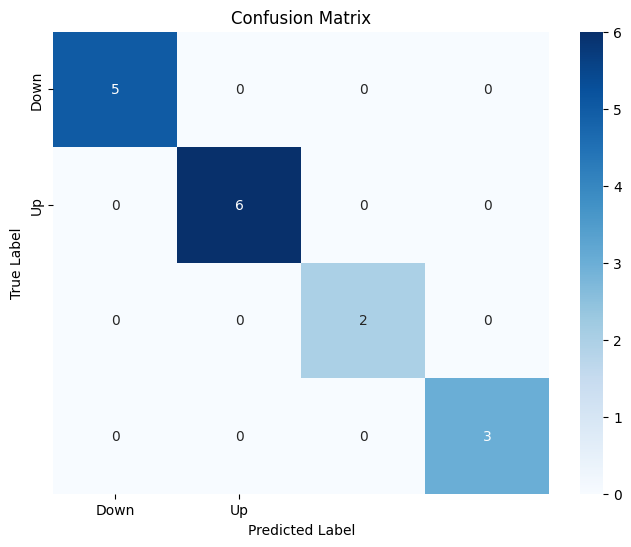

['scaler.joblib']

In [ ]:
# Train and evaluate the SVM model
svm_classifier = SVC(kernel='rbf')
svm_classifier.fit(X_train, y_train)
y_pred = svm_classifier.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'SVM Accuracy: {accuracy:.3%}')

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Save the trained SVM model
dump(svm_classifier, 'svm_classifier.joblib')
dump(scaler, 'scaler.joblib')  # Assumes you already created and fit a StandardScaler named 'scaler'

KNN accuracy: 100.000%


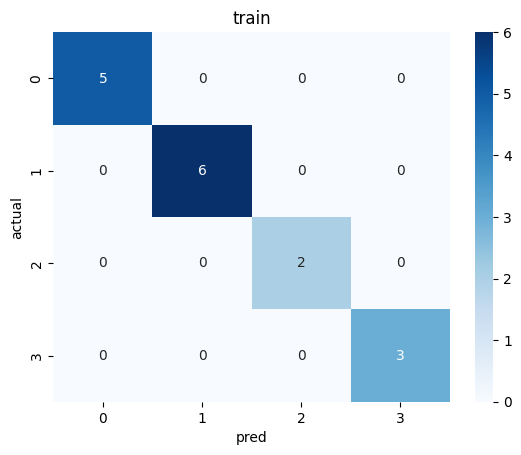

In [ ]:
n_neighbors=3
knn_classifier = KNeighborsClassifier(n_neighbors=n_neighbors)

# Train the classifier
knn_classifier.fit(X_train, y_train)

# Perform prediction on the test set
y_pred = knn_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN accuracy: {accuracy:.3%}')

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues")
plt.title('train')
plt.xlabel('pred')
plt.ylabel('actual')
plt.show()

In [ ]:
def predict_new_data(file_path, model, scaler):
    """
    Predict the gesture for new test data.
    """

    # Load the new test data
    df = pd.read_csv(file_path)

    # Extract features
    features = extract_features(df)
    features_df = pd.DataFrame([features])  # Convert to DataFrame for consistency

    # Normalize the features using the same scaler
    features_normalized = scaler.transform(features_df)

    # Make prediction
    prediction = model.predict(features_normalized)

    # Map prediction to gesture label
    if prediction[0] == 0:
      gesture_label = 'Up'
    elif prediction[0] == 1:
      gesture_label = 'Down'
    elif prediction[0] == 2:
      gesture_label = 'Left'
    elif prediction[0] == 3:
      gesture_label = 'Right'
    return gesture_label

# Example usage
new_test_file = 'trail_1.csv'  # Replace with the actual file path
predicted_gesture = predict_new_data(new_test_file, svm_classifier, scaler)
print(f'The predicted gesture is: {predicted_gesture}')

The predicted gesture is: Up
